**Dataset**: Intel Image Classification \
This dataset contains approximately 25,000 images across six classes, buildings, forest, glacier, mountain, sea, and street. The dataset is split into training and testing sets.

https://www.kaggle.com/datasets/puneet6060/intel-image-classification

<h1> Task 2

Part 1: Variational Autoencoder (VAE)

A Variational Autoencoder (VAE) is a generative model designed to learn a compressed, continuous representation of input data while being able to generate new, similar samples. It consists of three key components: the encoder, the sampling layer, and the decoder. The encoder maps the input data to a set of latent parameters (mean and variance), representing a probability distribution over the latent space rather than a single point, which allows the model to capture uncertainty and variability. The sampling layer draws samples from this latent distribution, enabling the network to generate diverse outputs rather than memorizing the training data. The decoder then reconstructs the original data from these latent samples, learning to generate realistic inputs that match the training distribution. The overall VAE model combines these components and is trained using a loss function that balances reconstruction accuracy (how close the output is to the input) and KL divergence (ensuring the latent space follows a normal distribution). This structure allows VAEs to perform dimensionality reduction, generate new data, and model complex data distributions in a probabilistic way.

In [55]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# unzip file
!unzip "archive (3).zip"

# load dataset
IMG_SIZE = (64, 64)
BATCH_SIZE = 32 # 32 images per bacth

# load images from seg_train
train_data = tf.keras.preprocessing.image_dataset_from_directory(
  "/content/seg_train/seg_train",
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE
)

# normalize pixel values to [0,1] range for VAE input
train_data = train_data.map(lambda x, y: (x/255.0, x/255.0))  # input = output for reconstruction

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jpg  
  inflating: seg_train/seg_train/mountain/7695.jp

In [56]:
# encoder for VAE
latent_dim = 128 # size of latent vector - dimensionality of compressed representation

encoder = tf.keras.Sequential([
  layers.Input(shape=(64,64,3)), # input - 64x64 RGB image
  layers.Conv2D(32, 3, strides=2, activation='relu'), # convolution + downsampling
  layers.Conv2D(64, 3, strides=2, activation='relu'), # deeper feature extraction
  layers.Flatten(), # flatten to vector
  layers.Dense(256, activation='relu'), # fully connected layer

  # output - mean + log variance for latent distribution
  layers.Dense(latent_dim + latent_dim)
])

In [57]:
# sampling layer
'''
Implements the reparameterization trick to allow backpropagation
through the sampling process

The layer takes the mean and log variance of the latent distribution
and returns a sampled latent vector

Methods:
  call(inputs)
    Performs sampling using the reparameterization trick

Parameters:
  inputs: tuple
            - z_mean: Tensor of shape (batch_size, latent_dim)
            - z_log_var: Tensor of shape (batch_size, latent_dim)

Returns:
  Tensor
    Sampled latent vector of shape (batch_size, latent_dim)
'''

class Sampling(layers.Layer):
  def call(self, inputs):
      z_mean, z_log_var = inputs # input - mean and log variance from encoder
      epsilon = tf.random.normal(shape=tf.shape(z_mean)) # random noise
      return z_mean + tf.exp(0.5 * z_log_var) * epsilon # aample latent vector

In [58]:
# decoder for VAE
decoder = tf.keras.Sequential([
  layers.Input(shape=(latent_dim,)), # input - latent vector
  layers.Dense(16*16*64, activation='relu'), # expand latent vector to feature map
  layers.Reshape((16,16,64)),

  # unsampling laters to reconstruct image
  layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
  layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
  layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same') # output image (values [0,1])
])

In [59]:
# VAE model
'''
Model consists of an encoder, a sampling layer, and a decoder
It learns a latent representation of the input data and reconstructs
the original input from this compressed representation

Methods:
  train_step(data)
  Performs one training step including forward pass,
  oss computation, and weight updates

Parameters:
  encoder: tf.keras.Model
    Encoder network that maps inputs to latent parameters

  decoder: tf.keras.Model
    Decoder network that reconstructs images from latent vectors
'''

class VAE(tf.keras.Model):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.sampling = Sampling()
    self.loss_tracker = tf.keras.metrics.Mean(name="loss")  # metric for logging

  @property
  def metrics(self):
    return [self.loss_tracker]  # Keras uses this for logging

  '''
  Executes one training step for VAE

  Parameters:
    data: tuple
      bBatch of (images, labels) - labels are ignored

  Returns:
    dict
      Dictionary containing total loss for batch
  '''
  def train_step(self, data):
    images, labels = data  # labels are ignored but given a variable name

    with tf.GradientTape() as tape:
        # encode
        z_params = self.encoder(images)
        z_mean, z_log_var = tf.split(z_params, 2, axis=1)

        # sample
        z = self.sampling([z_mean, z_log_var])

        # decode / reconstruct
        reconstruction = self.decoder(z)

        # reconstruction loss: average over all pixels & channels
        recon_loss = tf.keras.losses.binary_crossentropy(images, reconstruction)
        recon_loss = tf.reduce_mean(recon_loss)  # now in a reasonable range

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        # total VAE loss
        total_loss = recon_loss + kl_loss * 0.0001

    # compute gradients and apply
    grads = tape.gradient(total_loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    # update metric for logging
    self.loss_tracker.update_state(total_loss)

    return {"loss": self.loss_tracker.result()}

In [60]:
# train VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

vae.fit(train_data, epochs=70)

Epoch 1/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.6305
Epoch 2/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5900
Epoch 3/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5838
Epoch 4/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5807
Epoch 5/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5785
Epoch 6/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5768
Epoch 7/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5755
Epoch 8/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5746
Epoch 9/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5739
Epoch 10/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5734
Epoch 11/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5729
Epoch 12/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5725
Epoch 13/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5721
Epoch 14/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5717
Epoch 15/70
439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

The training results show that the model’s loss decreases gradually from about 0.6305 in the first epoch to around 0.5660 by the 70th epoch. Most improvement occurs in the early epochs. After roughly 15–20 epochs, the loss begins to plateau and changes very little. The model quickly learns simpler patterns in the data but struggles to make further meaningful progress. Limited model capacity, a low learning rate, or inherent dataset difficulty may contribute to this. The very small overall decrease in loss implies underfitting. Only training loss is shown, so generalization to unseen data cannot be assessed. The model is stable and improving slightly but appears to be reaching a performance ceiling, with minimal gains after the early stages of training.

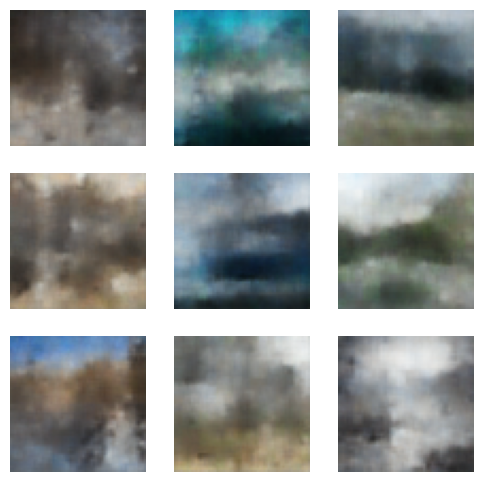

In [61]:
# generate images from VAE
import matplotlib.pyplot as plt

# sample random latent vectors
z = tf.random.normal(shape=(9, latent_dim))
generated_images = decoder(z)

# display images
plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(generated_images[i])
  plt.axis("off")
plt.show()

The generated images from the VAE are very blurry and lack clear structure. The model captures general color distributions rather than meaningful visual features like edges or object shapes. Broad patterns such as blues for sky and greens/browns for land are learned, but everything appears smoothed and indistinct. VAEs model data probabilistically, and the loss function encourages averaging. Instead of reconstructing a specific tree or building, the model produces an average of many possible images, resulting in soft, blob-like outputs.

The loss steadily decreases from about 0.63 to 0.566 and quickly plateaus, indicating the model has reached the limit of what it can learn with its current architecture. Reconstruction loss, especially mean squared error, penalizes pixel differences and encourages averaging. KL divergence regularizes the latent space and prevents memorizing detailed structures. A strong KL term can compress the latent space and cause the decoder to generate generic outputs, a phenomenon related to posterior collapse.

The dataset contains diverse real-world scenes, such as buildings, forests, and landscapes. The simple VAE struggles to capture all variation and instead learns an average scene, leading to blurred results. The VAE is functioning correctly but is limited by the trade-offs of the architecture and loss design.

Part 2: Generative Adversarial Networks (GANs)

A Generative Adversarial Network (GAN) is a type of neural network designed for generative tasks, where the goal is to produce realistic new data samples similar to a given training dataset. A GAN consists of two main components: the generator and the discriminator. The generator takes random noise as input and creates synthetic data samples, attempting to mimic the real data distribution. The discriminator evaluates samples and predicts whether each one is real (from the training data) or fake (produced by the generator). The two networks are trained adversarially, meaning the generator tries to fool the discriminator, while the discriminator tries to correctly distinguish real from fake samples.

The training process involves defining a loss function for both networks: the discriminator’s loss measures how well it classifies real vs. fake samples, and the generator’s loss measures how well it fools the discriminator. Optimizers, such as Adam, are used to update the weights of both networks through backpropagation. During training, the generator and discriminator are updated in alternating steps. Over time, the generator learns to produce increasingly realistic outputs, while the discriminator becomes better at detecting fakes. Proper balancing of the generator and discriminator, along with careful tuning of learning rates and loss functions, is critical; otherwise, training can fail due to mode collapse or vanishing gradients. GANs are widely used for image synthesis, data augmentation, and creative applications, providing a powerful framework for modeling complex data distributions.

In [62]:
# data preparation for GAN
train_data = tf.keras.preprocessing.image_dataset_from_directory(
  "seg_train",
  image_size=(64,64),
  batch_size=32
)

train_data = train_data.map(lambda x, y: (x - 127.5) / 127.5)  # normalize to [-1,1]

Found 14034 files belonging to 1 classes.


In [63]:
# generator
'''
Builds generator model for GAN

Takes a random noise vector as input and produces
a synthetic image, rogressively upsamples the noise vector
into a full-sized image using transposed convolutions

Returns:
  tf.keras.Model
  Generator model

'''
def build_generator():
  model = models.Sequential([
    layers.Dense(8*8*256, use_bias=False, input_shape=(100,)), # input - random noise vector
    layers.BatchNormalization(),
    layers.LeakyReLU(),
    layers.Reshape((8,8,256)), # reshape to 8x8 feature map

    # upsample to 16x16
    layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    # upsample to 32x32
    layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    # upsample to 64x64
    layers.Conv2DTranspose(3, 5, strides=2, padding='same', use_bias=False, activation='tanh')
  ])
  return model

In [64]:
# discriminator
'''
Builds the discriminator model for GAN

Discriminator is binary classifier that distinguishes between
real images and fake images generated by generator

Returns:
  tf.keras.Model
    Discriminator model
'''
def build_discriminator():
  model = models.Sequential([
    layers.Conv2D(64, 5, strides=2, padding='same', input_shape=(64,64,3)),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 5, strides=2, padding='same'),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1) # output - probability image is real
  ])
  return model

In [65]:
# loss + optimizer
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

'''
Computes generator loss for GAN training

Generator aims to fool discriminator, so loss
is calculated based on how well discriminator classifies
generated images as real

Parameters:
  fake_output: Tensor
    Discriminator predictions on generated images.

Returns:
  Tensor
    Generator loss value
'''
def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output), fake_output)


'''
Computes the discriminator loss for GAN training

The discriminator learns to distinguish real images from fake ones

Parameters:
  real_output: Tensor
    Discriminator predictions on real images

  fake_output: Tensor
    Discriminator predictions on generated (fake) images

Returns:
  Tensor
    Total discriminator loss
'''
def discriminator_loss(real_output, fake_output):
  real_loss = cross_entropy(tf.ones_like(real_output), real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
  return real_loss + fake_loss

# build GAN models
generator = build_generator()
discriminator = build_discriminator()

gen_opt = tf.keras.optimizers.Adam(1e-4)
disc_opt = tf.keras.optimizers.Adam(1e-4)

In [66]:
# training function
'''
Performs one training step for the GAN

This function updates both the generator and discriminator:
- Discriminator learns to classify real vs fake images
- Generator learns to fool the discriminator

Parameters:
  images: Tensor
    Batch of real images from dataset
'''
@tf.function
def train_step(images):
  noise = tf.random.normal([32, 100]) # random noise batch

  #  forward pass + compute gradients
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_images = generator(noise)
    real_output = discriminator(images)
    fake_output = discriminator(generated_images)

    gen_loss = generator_loss(fake_output)
    disc_loss = discriminator_loss(real_output, fake_output)

  # update generator and discriminator weights
  gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
  gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

  gen_opt.apply_gradients(zip(gradients_gen, generator.trainable_variables))
  disc_opt.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

  return gen_loss, disc_loss

In [67]:
# train GAN
import numpy as np

EPOCHS = 100

for epoch in range(EPOCHS):
  gen_losses = []
  disc_losses = []

  for image_batch in train_data:
    # perform one training step: update generator and discriminator weights
    # train_step returns generator loss and discriminator loss for this batch
    g_loss, d_loss = train_step(image_batch)

    # convert tensor to float
    gen_losses.append(g_loss.numpy())
    disc_losses.append(d_loss.numpy())

  avg_gen_loss = np.mean(gen_losses)
  avg_disc_loss = np.mean(disc_losses)

  print(f"Epoch {epoch+1}/{EPOCHS} - gen_loss: {avg_gen_loss:.4f}, disc_loss: {avg_disc_loss:.4f}")

Epoch 1/100 - gen_loss: 4.3759, disc_loss: 0.3117
Epoch 2/100 - gen_loss: 3.1557, disc_loss: 0.4920
Epoch 3/100 - gen_loss: 2.7501, disc_loss: 0.4427
Epoch 4/100 - gen_loss: 2.5579, disc_loss: 0.4748
Epoch 5/100 - gen_loss: 2.1952, disc_loss: 0.5507
Epoch 6/100 - gen_loss: 2.1411, disc_loss: 0.6347
Epoch 7/100 - gen_loss: 1.9662, disc_loss: 0.6514
Epoch 8/100 - gen_loss: 2.6065, disc_loss: 0.7481
Epoch 9/100 - gen_loss: 2.0563, disc_loss: 0.6577
Epoch 10/100 - gen_loss: 1.9663, disc_loss: 0.8635
Epoch 11/100 - gen_loss: 1.7482, disc_loss: 0.7236
Epoch 12/100 - gen_loss: 1.7761, disc_loss: 0.8825
Epoch 13/100 - gen_loss: 1.8044, disc_loss: 1.0092
Epoch 14/100 - gen_loss: 1.5728, disc_loss: 0.8402
Epoch 15/100 - gen_loss: 1.6274, disc_loss: 0.9743
Epoch 16/100 - gen_loss: 1.6951, disc_loss: 1.2000
Epoch 17/100 - gen_loss: 1.7124, disc_loss: 1.1308
Epoch 18/100 - gen_loss: 1.4950, disc_loss: 0.9005
Epoch 19/100 - gen_loss: 1.6931, disc_loss: 1.2878
Epoch 20/100 - gen_loss: 1.3971, disc_lo

The training results show typical GAN behavior. The generator loss (gen_loss) and discriminator loss (disc_loss) fluctuate and try to balance each other over time. Generator loss drops from 4.3759 in epoch 1 to around 2 within the first few epochs, indicating the generator quickly learns to produce more realistic outputs. After this early improvement, generator loss oscillates between roughly 1.4 and 2.7 for the remainder of training, showing that the generator adjusts in response to the discriminator’s changing strength.

Discriminator loss starts low at 0.3117, then increases and stabilizes around 0.7–1.2 with noticeable fluctuations. The discriminator initially distinguishes real from fake samples well, then becomes less certain as the generator improves. The discriminator does not collapse or dominate completely, indicating training remains somewhat balanced.

The generator and discriminator show characteristic adversarial dynamics. Persistent oscillations and lack of steady convergence in both losses indicate training is somewhat unstable and has not reached an optimal equilibrium.

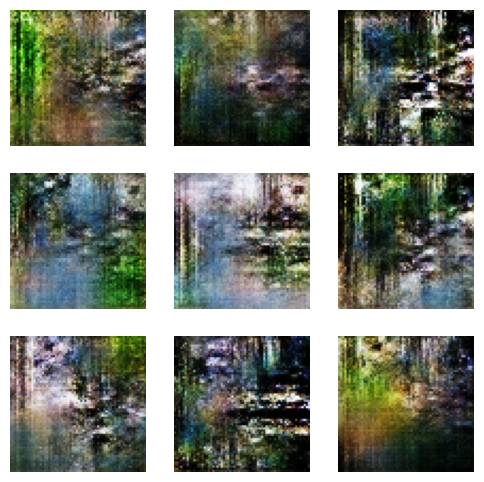

In [68]:
# images
noise = tf.random.normal([9, 100])
generated_images = generator(noise)

plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow((generated_images[i] + 1) / 2) # scale from [-1,1] to [0,1] for display
  plt.axis("off")
plt.show()

The images show strong abstract structure with blurred textures and color blending. The generator captures general distributions of the original dataset, but fine details and sharp object boundaries are missing. This occurs in early to mid stages of GAN training when generating complex natural images such as landscapes or buildings.

The generator loss starts high (\~4.37) and decreases overall, fluctuating between ~1.4 and 2, which is normal due to adversarial dynamics. The discriminator loss starts low (\~0.31) and gradually rises to \~0.65–1.4. Fluctuations occur as the generator and discriminator compete.

The color distribution is diverse, indicating the GAN is learning global dataset features. Textures are noisy and smeared, showing the generator has not fully learned sharp structural details. Some images have vertical and horizontal streaking, suggesting mode collapse tendencies or insufficient convolutional depth in the generator. Training for 100 epochs produces rough approximations rather than fully realistic samples. Different numbers of epochs contribute significantly to image quality. Adjusting learning rates or using techniques like gradient penalty or spectral normalization may improve fidelity.

The GAN learns general patterns of the Intel dataset but requires more epochs, potentially deeper architectures, and careful tuning to generate recognizable, sharp images.

**Comparision of Models**

The Variational Autoencoder (VAE) learns a probabilistic latent representation through an encoder, sampling layer, and decoder. Its loss combines reconstruction error with KL divergence, forcing the model to capture overall data distribution rather than memorizing specific details. After 70 epochs, the VAE produces very blurry images with broad color patterns such as blues for sky and greens or browns for land. Edges, structure, and fine details are mostly absent. The loss decreases gradually from about 0.63 to 0.566, plateauing after the early epochs. This indicates that the model quickly learns simple patterns but cannot improve further due to architectural limitations and the averaging effect of its probabilistic design.

The Generative Adversarial Network (GAN) uses an adversarial setup with a generator creating images from random noise and a discriminator distinguishing real from fake images. Training shows oscillations in generator and discriminator losses due to the competitive dynamics. The generator loss decreases from roughly 4.37 to around 2.12 over 100 epochs, while the discriminator loss rises from 0.31 to approximately 0.65–1.4. These dynamics indicate that the generator is learning to produce more realistic images while the discriminator continues improving its ability to detect fakes.

GAN-generated images show better-defined structures and more vivid colors than VAE outputs, but textures remain noisy, streaked, and lacking fine detail. The generator captures global features and approximate object shapes but does not fully resolve sharp edges or small structures. The differences in losses and generated image quality indicate that VAEs prioritize smooth, averaged reconstructions due to the KL regularization, while GANs produce sharper and more varied outputs at the cost of less stable training. The number of epochs and tuning of hyperparameters significantly affect the quality of GAN outputs.